In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sklearn.linear_model import Ridge
import pandas as pd
import os
%matplotlib inline

In [2]:
os.chdir("/home/thappe/HeaT")

from HeaT.dyn_decomp import *

In [3]:
data_path = "/home/thappe/data/"

In [4]:
ls /home/thappe/data/ 

1940-2023_T2M_westEU_JJA_LENTISGRID.nc
1940-2023_T2M_westEU_JJA.nc
LENTIS_gridarea_europeWest.nc
LinRegrDetrendedperGridpoint_MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc
MSLP_era5_NHmidlats_0.25degr_1940_2023_JJA.nc*
NASA_GMST.csv
STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc
T2M_decomposition/


##  ERA5 Data

In [5]:
T2M_file = "1940-2023_T2M_westEU_JJA.nc"
STREAM500_file = "STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc"

In [6]:
t2m = xr.open_dataset(f"{data_path}{T2M_file}")["t2m"] - 273.15
stream500 = xr.open_dataset(f"{data_path}{STREAM500_file}")

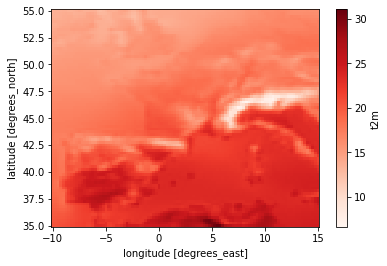

In [59]:
t2m_climatology = t2m.mean(dim="time")
t2m_climatology.plot(cmap="Reds")


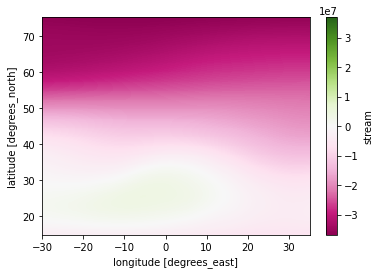

In [7]:
stream500_clim = stream500['stream'].mean(dim="time")
stream500_clim.plot(cmap="PiYG")


## NASA yearly GMST --> moet dit nog grotere lowess?

Perhaps a sensitivity test later on lowess=50 or so

In [7]:
yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)

<AxesSubplot:xlabel='Year'>

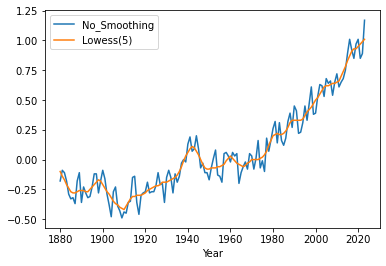

In [8]:
yearly_GMST.plot()

## prepare data for one grid point first

Text(0.5, 1.0, 'T2M gridpoint to predict \n and extent for dynamics')

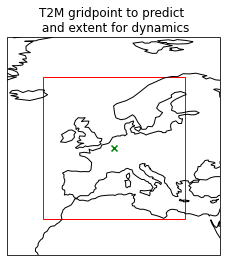

In [16]:
lon = 5
lat = 50
window=20 #sensitiity is relatively low 

lower_year = 1940 #(including)
upper_year = 2022 #(including)

standardize = True #whether to standardize the in and output data with respect to time axis (per gridpoint!)


lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)

## plot
import matplotlib.patches as mpatches

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([lon-(window+10), lon+(window+10), lat-(window+10), lat+(window+10)])
ax.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
ax.coastlines()
ax.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x')
plt.title("T2M gridpoint to predict \n and extent for dynamics")

In [15]:
def decompose_one_gridpoint_crossval_testing(Y_, X_, penalty, 
                            t2m_mean, t2m_std,
                            stream500_x2, GMST_x1,
                            K=5
                            ):
    """
    Takes prepared data from _preprocess_data() and fits the ridge model for one gridpoint.
    Takes t2m_mean and std values to calculate the non-standardize t2m data    
    K determines amount of folds for cross validation
    
    returns: optimal_lambda, MSE, R2, t2m_thermodynamic_std, t2m_thermodynamic, t2m_dynamic_std, t2m_dynamic
    
    """
    from custom_enet import CustomENet, CustomENetCV
    from scipy.optimize import minimize_scalar
    from sklearn.linear_model import ElasticNetCV
    from sklearn.preprocessing import StandardScaler
    from statsmodels.api import OLS, add_constant
    from sklearn.metrics import mean_squared_error, r2_score
    from sklearn.model_selection import RepeatedKFold
    
    #set cross validation and lambda (alphas) values 
    cv = RepeatedKFold(n_splits=K, n_repeats=1, random_state=2023) 
    #alphas = np.geomspace(0.01, 10, num=100) #penalty for regularization (also called lambda)
    #alphas = np.geomspace(0.01, 20, num=100)
    alphas = np.geomspace(0.01, 100, num=50)

    
    #fit the model
    model_ce = CustomENetCV(cv, l1_ratio=0, 
                            standardize=False, #already standardized
                            fit_intercept=False, #y is centered (standadized) 
                            refit=True, #to refit the last model with the best alpha value 
                            alphas=alphas, 
                            tol=1e-4, #dec of coefficients
                            max_iter=5000, #needs 5000 misschien minder maar even om de code te testen
                            random_state=2023)
    model_ce.fit(X_, Y_, penalty)
    
    #Predict and calculate validation scores 
    y_pred = model_ce.predict(X_).reshape(-1, 1)
    MSE = mean_squared_error(Y_, y_pred, squared=False)
    R2 = r2_score(Y_, y_pred)
    
    #Grab optimal lambda from the fitted model (based on minimum MSE)
    optimal_lambda = model_ce.alpha_best 
    
    path_errors = model_ce.cv_errs
    
    weights = model_ce.w
    

    return optimal_lambda, MSE, R2, path_errors, weights

   




In [7]:
def from_errors_to_best_alpha(alphas, error_path):
    """
    for 1 cross validation run (so for 1 gridpoint), calculate the best alpha value.
    the best alpha is the largest alpha for which the error is still within one standard error
    
    returns best alpha value and index corresponding to this
    """
    #take the mean over the different K-folds for each alpha
    error_path_mean = error_path.mean(axis=1)
    #calculate the standard error 
    standard_error = error_path_mean.std() #do you take the std of the mean or all?
    #print(standard_error)
    
    # minimum error 
    min_error = min(error_path_mean)
    error_plus = min_error + standard_error #find lowest error, plus 1 std error
    
    ## find alpha corresponding to this error
    idx_plus = np.abs(error_path_mean - error_plus).argmin() #find the error value closest to the lowest error minus 1 std error
    alpha_plus = alphas[idx_plus] #find the alpha that belongs to this 

    return alpha_plus, idx_plus

### Some random gridpoints to test for alpha using cross validation

In [9]:
## LOAD DATA

T2M_file = "1940-2023_T2M_westEU_JJA.nc"
t2m = xr.open_dataset(f"{data_path}{T2M_file}")["t2m"] - 273.15

STREAM500_file = "STREAM500_era5_ExtendedWestEU_0.25degr_1940_2022_JJA.nc"
stream500 = xr.open_dataset(f"{data_path}{STREAM500_file}")["stream"]

yearly_GMST = pd.read_csv(f"{data_path}NASA_GMST.csv", delimiter=";", skiprows=1, index_col=0)

## SET GLOBAL VARIABLES
lower_year=1940 
upper_year=2022
window=20

K_cross_validation = 2 #set to 5 later 


## assert the stream500 is large enough for the set window size, given t2m
lat_extent_exeeded = (max(t2m.latitude)+window > max(stream500.latitude)) or (min(t2m.latitude)-window > min(stream500.latitude))
lon_extent_exeeded = (max(t2m.longitude)+window > max(stream500.longitude)) or (min(t2m.longitude)-window > min(stream500.longitude))

if lat_extent_exeeded or lon_extent_exeeded:
    print("stream500 extent is not enough for the window size given.")
    print(f"Stream500 extent is lat:{(int(min(stream500.latitude))), int(max(stream500.latitude))}, lon:{int(min(stream500.longitude)), int(max(stream500.longitude))}")
    print(f"t2m extent is lat:{(int(min(t2m.latitude))), int(max(t2m.latitude))}, lon:{int(min(t2m.longitude)), int(max(t2m.longitude))}")
    print(f"window is {window}")
    raise ValueError(f'lat or lon extent is exceeded: Lat_exeeded={lat_extent_exeeded} and Lon_exeeded={lon_extent_exeeded}')

In [30]:
## to select random indexes for random lat lon combinations to test lambda values

# import random
# rand_lats = [random.randint(0, t2m.latitude.shape[0]-1) for p in range(0, 10)]
# rand_lons = [random.randint(0, t2m.longitude.shape[0]-1) for p in range(0, 10)]

# location = []
# lambda_values = []

In [6]:
random_coords = [(50., 5.), (53.25, 4.25), (50.5, 5.75), (37.5, 2.75), (48.5, 5.75), (49.0, 3.75), (46.25, -9.5), (36.75, 12.75)]
optimal_lambda_with_minMSE = [np.NaN, 0.049770235643321115, 0.07054802310718646, 0.01, 0.016297508346206444, 0.01747528400007684, 0.049770235643321115, 0.012328467394420659]
random_coords

[(50.0, 5.0),
 (53.25, 4.25),
 (50.5, 5.75),
 (37.5, 2.75),
 (48.5, 5.75),
 (49.0, 3.75),
 (46.25, -9.5),
 (36.75, 12.75)]

In [11]:
random_coords[0]

(53.25, 4.25)

In [10]:
location = []
lambda_values_with_minMSE = []
best_lambda_values_within1STDError = []
weights_values = []
error_paths = []

In [50]:
K_cross_validation = 2 # just for the sake of time
        
# for i, coords in enumerate([(50, 5), (36.75, 12.75),]):
for i, coords in enumerate([(53.25, 4.25), (50.5, 5.75), (37.5, 2.75), (48.5, 5.75), (49.0, 3.75), (46.25, -9.5)]):
    
#for i, coords in enumerate(random_coords):
    
    lat, lon = coords
    print(i, lat, lon) 
    
    ## first process the data correctly
    Y_, X_, penalty, t2m_mean, t2m_std, stream500_x2, GMST_x1 = preprocess_data(
        lon, lat, t2m, stream500, yearly_GMST,
        lower_year=lower_year, upper_year=upper_year, window=window)
    ## fit the model for this gridpoint
    optimal_lambda, MSE, R2, error_path, weights = decompose_one_gridpoint_crossval_testing(
        Y_, X_, penalty, t2m_mean, t2m_std, stream500_x2, GMST_x1, K=K_cross_validation)

    ### save data for cross validation
    lambda_values_with_minMSE.append(optimal_lambda)
    location.append((lat,lon))
    alphas = np.geomspace(0.01, 100, num=50)
    best_alpha, alpha_ind = from_errors_to_best_alpha(alphas, error_path)
    best_lambda_values_within1STDError.append(best_alpha)
    weights_values.append(weights) #this weight is not from 'best alpha' but from the one with the minimum alpha
    error_paths.append(error_path)


0 53.25 4.25
CV round 1
CV round 2


/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.004399930662281315
1 50.5 5.75
CV round 1
CV round 2


/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.004106702888042303
2 37.5 2.75
CV round 1
CV round 2


...

/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.005082069668419475
4 49.0 3.75
CV round 1
CV round 2


/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


0.004963105813531001
5 46.25 -9.5
CV round 1
CV round 2
0.00842578359208484


/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [51]:
print("locations", location)
print("lambdas", lambda_values_with_minMSE)
print("best_lambdas", best_lambda_values_within1STDError)
print("mean best_lambda is", np.mean(best_lambda_values_within1STDError))

locations [(50, 5), (50, 5), (36.75, 12.75), (53.25, 4.25), (50.5, 5.75), (37.5, 2.75), (48.5, 5.75), (49.0, 3.75), (46.25, -9.5)]
lambdas [0.1997127334530273, 0.20235896477251566, 0.014563484775012436, 0.2442053094548651, 0.20235896477251566, 0.014563484775012436, 0.20235896477251566, 0.13894954943731375, 0.13894954943731375]
best_lambdas [5.963623316594643, 1.325711365590108, 0.01, 5.963623316594643, 2.811768697974228, 8.68511373751352, 5.963623316594643, 5.963623316594643]
mean best_lambda is 4.585885883432054


In [54]:
print("locations", location[1:])
print("lambdas", lambda_values_with_minMSE[1:])
print("mean lambda from model", np.mean(lambda_values_with_minMSE[1:]))
print("best_lambdas", best_lambda_values_within1STDError[1:])
print("mean best_lambda is", np.mean(best_lambda_values_within1STDError[1:]))

locations [(50, 5), (36.75, 12.75), (53.25, 4.25), (50.5, 5.75), (37.5, 2.75), (48.5, 5.75), (49.0, 3.75), (46.25, -9.5)]
lambdas [0.20235896477251566, 0.014563484775012436, 0.2442053094548651, 0.20235896477251566, 0.014563484775012436, 0.20235896477251566, 0.13894954943731375, 0.13894954943731375]
mean lambda from model 0.14478853402463307
best_lambdas [1.325711365590108, 0.01, 5.963623316594643, 2.811768697974228, 8.68511373751352, 5.963623316594643, 5.963623316594643]
mean best_lambda is 4.389066250123112


### sensitivity of alphas and on how to calculate mean std error 

I think it is correct to take the MEAN first, see the plots 

In [ ]:
# for K=5 and lat,lon 50,5
# if calculating over MEAN errors for each alpha the std_error is 0.002119079066136223, and alpha_best = 0.932
# if calculating over all errors for each alpha the std_error is 0.009055220102176588, and alpha_best = 10.0

In [ ]:
# if calculating over MEAN errors for each alpha the std_error is 0.002330185089784838, and alpha_best = 1.07
# if calculating over all errors for each alpha the std_error is 0.007959851297248416, and alpha_best = 9.32


In [88]:
print(alpha_best, "largest alpha for which the error is within 1 standard error from the minimum")

1.072267222010323 largest alpha for which the error is within 1 standard error from the minimum


### plotting the error path along alphas, taking the mean error across different folds of the C.V.

In [20]:
error_path.shape

(50, 2)

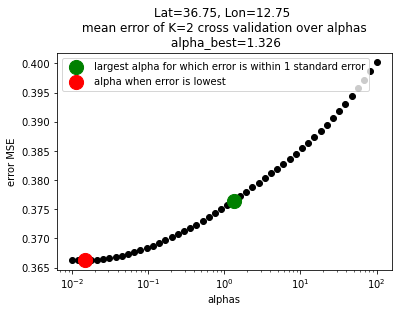

In [28]:
error_path_mean = error_path.mean(axis=1)

for i, alpha in enumerate(alphas):
    plt.scatter(alpha, error_path_mean[i], color='black')
         
plt.scatter(best_alpha, error_path_mean[alpha_ind], color="green", s=200,
            label="largest alpha for which error is within 1 standard error")   

min_error_index = np.argwhere(error_path_mean==min(error_path_mean))
plt.scatter(alphas[min_error_index], error_path_mean[min_error_index], color="red", s=200, 
            label="alpha when error is lowest")  

plt.xscale("log")
plt.title(f"Lat={lat}, Lon={lon} \n mean error of K={K_cross_validation} cross validation over alphas \n alpha_best={round(best_alpha,3)}")
plt.xlabel("alphas")
plt.ylabel("error MSE")
plt.legend()
    

### Here I refit the model using different alpha values (in this case alpha_best) to then plot the change in coefficients and also calculate the r2 schange

In [32]:
lon, lat

(12.75, 36.75)

In [33]:
Y_, X_, penalty, t2m_mean, t2m_std, stream500_x2, GMST_x1 = preprocess_data(
        lon, lat, t2m, stream500, yearly_GMST,
        lower_year=lower_year, upper_year=upper_year, window=window)

In [34]:
best_alpha, alpha_ind = from_errors_to_best_alpha(alphas, error_path)


0.010176976359749419


In [36]:
print("locations", location)
print("lambdas", lambda_values_with_minMSE)
print("best_lambdas", best_lambda_values_within1STDError)
print(best_alpha)

locations [(50, 5), (50, 5), (36.75, 12.75)]
lambdas [0.1997127334530273, 0.20235896477251566, 0.014563484775012436]
best_lambdas [5.963623316594643, 1.325711365590108]
1.325711365590108


In [38]:
from custom_enet import CustomENet, CustomENetCV

In [46]:
model_ce = CustomENet(l1_ratio=0, 
                        standardize=False, #already standardized
                        fit_intercept=False, #y is centered (standadized) 
                        alpha=10, #just to try  
                        tol=1e-4, #dec of coefficients
                        max_iter=5000, #needs 5000 misschien minder maar even om de code te testen
                        random_state=2023)

model_ce.fit(X_, Y_, penalty)

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model_ce.predict(X_).reshape(-1, 1)
MSE = mean_squared_error(Y_, y_pred, squared=False)
R2 = r2_score(Y_, y_pred)

/home/thappe/.local/lib/python3.10/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Text(0.5, 1.0, 'Coefficients of dynamical part of the regression \n for T2M in gridpoint denoted with X \n for best_alpha=1.326 R2=0.619')

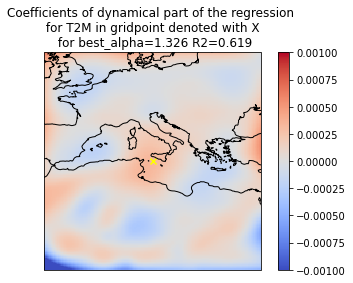

In [48]:
lat,lon= 36.75, 12.75
window=20
lon_bounds = (lon-window, lon+window)
lat_bounds = (lat-window, lat+window)

weights=model_ce.w
stream_weigths = weights[1:]
stream_weigths_reshaped = stream_weigths.reshape(161,161)


stream500_cut = stream500.sel(
    longitude=slice(lon_bounds[0], lon_bounds[1]), latitude=slice(lat_bounds[1], lat_bounds[0]))

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), 
                      subplot_kw={'projection': ccrs.PlateCarree()})

cs = ax.pcolormesh(stream500_cut.longitude, stream500_cut.latitude, 
              stream_weigths_reshaped, cmap="coolwarm",
             vmin=-0.001, vmax=0.001)
fig.colorbar(cs, ax=ax)

ax.coastlines()
ax.scatter(lon,lat, transform=ccrs.PlateCarree(), color='yellow', marker='x')
plt.title(f"Coefficients of dynamical part of the regression \n for T2M in gridpoint denoted with X \n for best_alpha={round(best_alpha,3)} R2={round(R2,3)}")


0
50 5
1
36.75 12.75
2
53.25 4.25
3
50.5 5.75
4
37.5 2.75
5
48.5 5.75
6
49.0 3.75
7
46.25 -9.5


Text(0.5, 1.0, 'T2M gridpoints for alpha validation \n mean lambda=4.389, n=8')

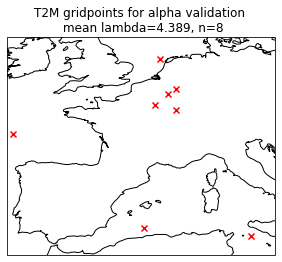

In [53]:
m_l = np.mean(best_lambda_values_within1STDError[1:])

## plot
import matplotlib.patches as mpatches

fig,ax = plt.subplots(nrows=1, ncols=1, figsize=(6,4), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-10, 15, 35, 55])

ax.coastlines()

for i, loc in enumerate(location[1:]):
    print(i)
    lat, lon = loc
    print(lat, lon)
    ax.scatter(lon,lat, transform=ccrs.PlateCarree(), color='r', marker='x')
    
plt.title(f"T2M gridpoints for alpha validation \n mean lambda={round(m_l,3)}, n={len(location[1:])}")

# some  old testing code below that shows the decomposition of t2m

In [35]:
t2m_cut = t2m.sel(time=t2m.time.dt.year>= lower_year)
t2m_cut= t2m_cut.sel(time=t2m_cut.time.dt.year<= upper_year)
t2m_cut = t2m_cut.sel(longitude=lon, latitude=lat)

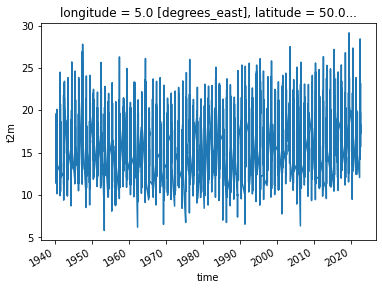

In [92]:
t2m_cut.plot()

In [69]:
stream500_x2.shape[1]

161

In [25]:
T2M_thermodynamical_std = GMSTw * GMST_x1

In [38]:
T2M_thermodynamical = (T2M_thermodynamical_std * t2m_std) # + t2m_mean

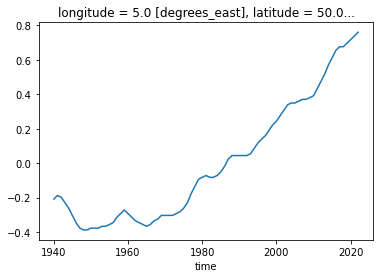

In [39]:
T2M_thermodynamical.plot()

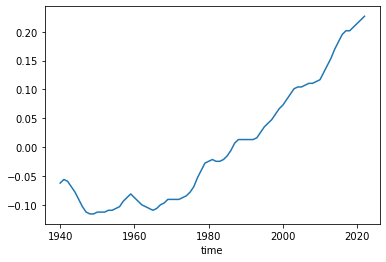

In [27]:
T2M_thermodynamical_std.plot()

In [30]:
T2M_dynamical_std = (stream_weigths_reshaped * stream500_x2).sum(dim=("longitude", "latitude"))

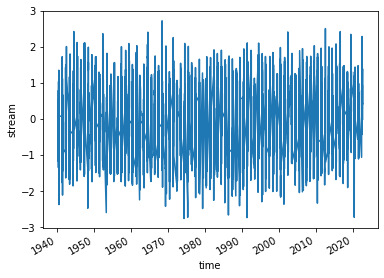

In [31]:
T2M_dynamical_std.plot()

In [48]:
T2M_dynamical = (T2M_dynamical_std * t2m_std ) + t2m_mean

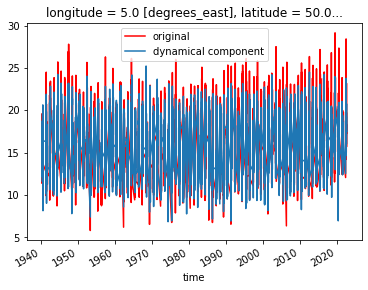

In [56]:
t2m_cut.plot(c="red", label="original")
T2M_dynamical.plot(label="dynamical component")
plt.legend()

####
for dynamical you can also predict using the features and setting GMST feature to a constant (e.g. mean of all GMST)

In [43]:
T2M_combined = T2M_thermodynamical.values + T2M_dynamical.values + t2m_mean.values

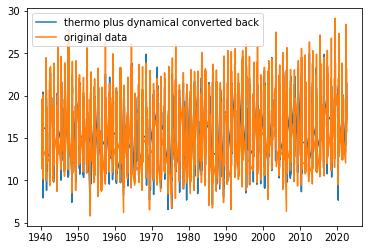

In [44]:
plt.plot(t2m_cut.time, T2M_combined, label="thermo plus dynamical converted back")
plt.plot(t2m_cut.time, t2m_cut, label="original data")
plt.legend()

Text(0.5, 1.0, 'R2=0.75')

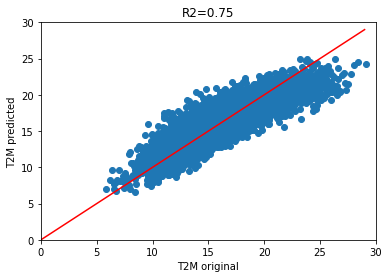

In [61]:
plt.scatter(t2m_cut.values, T2M_combined)
plt.xlim(0, 30)
plt.xlabel("T2M original")
plt.ylabel("T2M predicted")
plt.ylim(0, 30)
plt.plot(np.arange(0,30,1), np.arange(0,30,1), c='red')
plt.title(f"R2={round(r2, 2)}")

## predict the (standardized) temperature from the weights

##### thermodynamic component of temperature

In [70]:
T2M_dynamical = (stream_weigths_reshaped * stream500_x2).sum(dim=("longitude", "latitude"))
T2M_dynamical = T2M_dynamical.rename("T2M_dynamical")
T2M_dynamical.assign_attrs(units="Celsius", description="Standardized temperature data")

<xarray.DataArray 'T2M_dynamical' (time: 7636)>
array([-1.25363925, -0.41114392,  0.36928295, ...,  0.46976877,
        0.35349404,  0.42125191])
Coordinates:
  * time     (time) datetime64[ns] 1940-06-01T11:00:00 ... 2022-08-31T11:00:00
Attributes:
    units:        Celsius
    description:  Standardized temperature data

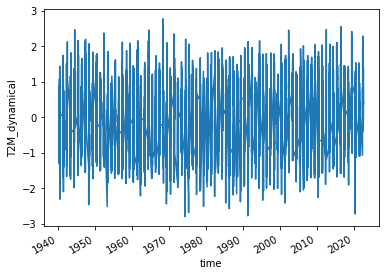

In [71]:
T2M_dynamical.plot()

##### thermodynamic component of temperature

In [77]:
T2M_thermodynamical = GMSTw * GSMT_x1
T2M_thermodynamical = T2M_thermodynamical.rename("T2M_thermodynamical")
T2M_thermodynamical.assign_attrs(units="Celsius", description="Standardized temperature data")

<xarray.DataArray 'T2M_thermodynamical' (time: 7636)>
array([-0.06371696, -0.06371696, -0.06371696, ...,  0.23241373,
        0.23241373,  0.23241373])
Coordinates:
  * time     (time) int64 1940 1940 1940 1940 1940 ... 2022 2022 2022 2022 2022
Attributes:
    units:        Celsius
    description:  Standardized temperature data

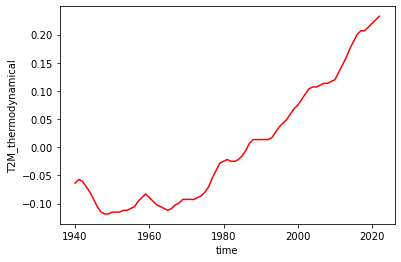

In [85]:
T2M_thermodynamical.plot(c="red", label="thermodynamic component of T")


Text(0, 0.5, 'Degrees C')

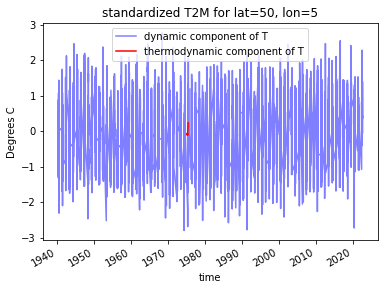

In [87]:
# T2M_thermodynamical.plot(c="red", label="thermodynamic component of T")

T2M_dynamical.plot(c="blue", label="dynamic component of T", alpha=0.5)
T2M_thermodynamical.plot(c="red", label="thermodynamic component of T")

plt.title(f"standardized T2M for lat={lat}, lon={lon}")
plt.legend()
plt.ylabel("Degrees C")

Text(0.5, 0.98, 'Lat=50, Lon=5')

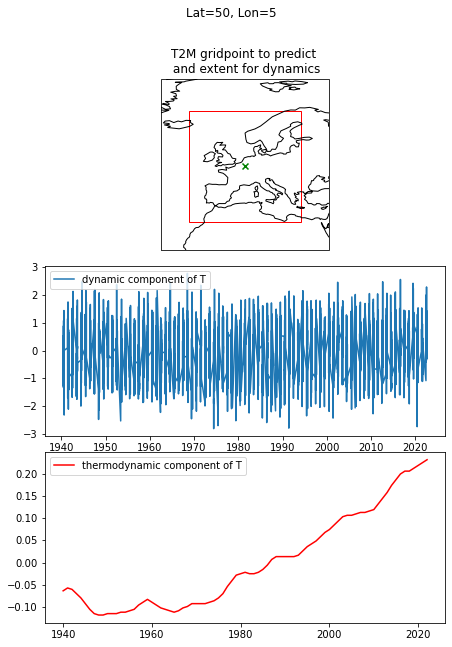

In [115]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15,10))
gs = fig.add_gridspec(6, 4)

ax1 = fig.add_subplot(gs[0:2, :], projection=ccrs.PlateCarree())
ax1.set_extent([lon-(window+10), lon+(window+10), lat-(window+10), lat+(window+10)])
ax1.add_patch(mpatches.Rectangle(xy=[lon_bounds[0],lat_bounds[0]], width=window*2, height=window*2,
                                facecolor='none', edgecolor='red',
                                transform=ccrs.PlateCarree()))
ax1.coastlines()
ax1.scatter(lon,lat, transform=ccrs.PlateCarree(), color='g', marker='x')

ax1.set_title("T2M gridpoint to predict \n and extent for dynamics")

####

ax2 = fig.add_subplot(gs[2:4, 1:3])
ax2.plot(T2M_dynamical.time, T2M_dynamical.values, label="dynamic component of T")
ax2.legend(loc="upper left")

ax3 = fig.add_subplot(gs[4:, 1:3])
ax3.plot(T2M_thermodynamical.time, T2M_thermodynamical.values, label="thermodynamic component of T", c="r")

ax3.legend(loc="upper left")

fig.suptitle(f"Lat={lat}, Lon={lon}")